<a href="https://colab.research.google.com/github/m42tk7246v-png/JCU_MA3832_Stephenson/blob/main/MA3832_Week1_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Workshop 1 Questions**

1. What is the tensor?

2. What is the advantage of storing data as *Tensor*?

3. What are the key functionalities of the *Pandas* library that are valuable for data science and AI?

4. Load the Penguin data from github: `https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv`

   a) What fraction of the data with bill length values missing?

   b) What fraction of the variables is numerical, categorical, or text?

   c) Load penguin data as tensor (Hints: Need to convert all variable to numeric value first)

   d) How many rows in the Penguin data?

   e) Modify the plot function defined the textbook to generate a scatter plot showing the relationship between penguin body mass and flipper length. (Use LLM if needed)

**1. What is a tensor?**
A tensor is a generalisation of scalars, vectors, and matrices to arbitrary numbers of dimensions:

Scalar — rank 0 tensor (a single number)
Vector — rank 1 tensor (1D array)
Matrix — rank 2 tensor (2D array)
Rank 3+ — e.g. a colour image is naturally a 3D tensor: height × width × channels (RGB)

In deep learning, tensors are the fundamental data structure that flows through a network — hence TensorFlow's name.

**2. Advantages of storing data as tensors:**

* GPU parallelism — tensors map directly onto GPU memory architecture, enabling massively parallel operations across thousands of cores simultaneously

* Unified abstraction — a single data structure handles inputs of any dimensionality (images, text sequences, video, tabular data) without special cases

* Automatic differentiation — frameworks like PyTorch and TensorFlow track computational graphs through tensor operations, enabling backpropagation without manual gradient derivation

* Vectorised operations — element-wise and matrix operations replace explicit loops, which is both faster and more expressive

* Hardware portability — the same tensor code can run on CPU, GPU, or TPU with minimal changes


**3. Key Pandas functionalities for data science and AI:**

* DataFrame — tabular data structure with labelled rows and columns, the workhorse of data wrangling

* Missing data handling — isnull(), dropna(), fillna() for detecting and imputing gaps

* Grouping and aggregation — groupby() for split-apply-combine operations

* Merging and joining — SQL-style joins between DataFrames

* Data type inspection — dtypes, describe() for quick profiling

* Filtering and indexing — boolean masking, loc/iloc
I/O — reading from CSV, Excel, SQL, JSON, Parquet with a single function call
Integration with ML pipelines — serves as the standard preprocessing layer before handing data off to NumPy arrays or tensors for model training

## Looking forward in the course: Tensors are the Fundamental Data Structure in Neural Networks

*A lot of the terminology in this block of explanatory text doesn't mean much to you yet. That's ok. Reading it will begin to sensitive you to some terms so when they turn up later you will begin to make connections.*

### Input as a tensor

Suppose you're training on images. A single 28×28 greyscale image is a rank-2 tensor (a matrix). But you don't feed one image at a time — you feed a *batch* of, say, 32 images simultaneously. That batch becomes a rank-3 tensor of shape (32, 28, 28). For colour images add the channel dimension: (32, 28, 28, 3).

That tensor is your starting point.

### Through each layer

Every layer in the network is essentially a tensor operation:

- A **dense (fully connected) layer** does a matrix multiplication: input tensor × weight matrix + bias vector → output tensor. The weights themselves are tensors.
- A **convolutional layer** slides a filter (a small tensor) across the input tensor, producing a new tensor of feature maps.
- **Activation functions** (ReLU, sigmoid etc.) are applied element-wise across the tensor, producing a new tensor of the same shape.
- **Pooling layers** reduce spatial dimensions, producing a smaller tensor.

At every step, a tensor goes in, an operation is applied, a new tensor comes out. Nothing else — just tensors transforming into tensors.

### The weights are tensors too

The *learnable parameters* of the network — the things that get updated during training — are themselves tensors stored in memory. A network with millions of parameters is just holding a large collection of tensors.

### Backpropagation

When you compute the loss (how wrong the prediction was), the framework needs to compute gradients — how much each weight contributed to the error. These gradients are also tensors, with exactly the same shape as the weight tensors they correspond to. The gradient update is then just elementwise tensor arithmetic.




**4. Loading and examining a data set**

Let's start by using the functionality of pandas to load the data set of the exercise and examine it, as we would in usual data science good practice.


In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"
df = pd.read_csv(url)

# Basic inspection
print("Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nSummary statistics:")
display(df.describe())

Shape: (344, 7)

First 5 rows:


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE



Data types:
species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object

Missing values:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Summary statistics:


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


So much so far looks like a Python version of R.

A major difference with using tensors in Python versus data frames (or tibbles) in R, is tensors assume all data is present and in the correct format for maniupluation. They also assume all data is numeric, so any quantities that are not already numeric must be first encoded

Hence to load the data as a tensor we need to do a two things in this instance

* Drop all rows with NAs

* Encode the character strings. This uses a method from a preprocessing library upstream from PyTorch. It is possible to do this in the PyTorch ecosystem but doing it as illustrated below is considered normal practice.





In [ ]:
import torch
import pandas as pd
from sklearn.preprocessing import LabelEncoder

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"
df = pd.read_csv(url)

# Step 1: drop rows with any missing values
# Note that we explicitly make a copy of the dataframe here. Otherwise
# pandas just creates what is called a view of the data frame without
# dedicating new memory to it. This generate warnings at run time in Step 2
# as pandas gets nervous that we are making changes to the original version
# of the dataframe
df_clean = df.dropna().copy()

# Step 2: encode categorical columns as integers
le = LabelEncoder()
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = le.fit_transform(df_clean[col])

# Step 3: convert to tensor
tensor = torch.tensor(df_clean.values, dtype=torch.float32)

print("Tensor shape:", tensor.shape)
print("Tensor dtype:", tensor.dtype)
print(tensor)

Tensor shape: torch.Size([333, 7])
Tensor dtype: torch.float32
tensor([[0.0000e+00, 2.0000e+00, 3.9100e+01,  ..., 1.8100e+02, 3.7500e+03,
         1.0000e+00],
        [0.0000e+00, 2.0000e+00, 3.9500e+01,  ..., 1.8600e+02, 3.8000e+03,
         0.0000e+00],
        [0.0000e+00, 2.0000e+00, 4.0300e+01,  ..., 1.9500e+02, 3.2500e+03,
         0.0000e+00],
        ...,
        [2.0000e+00, 0.0000e+00, 5.0400e+01,  ..., 2.2200e+02, 5.7500e+03,
         1.0000e+00],
        [2.0000e+00, 0.0000e+00, 4.5200e+01,  ..., 2.1200e+02, 5.2000e+03,
         0.0000e+00],
        [2.0000e+00, 0.0000e+00, 4.9900e+01,  ..., 2.1300e+02, 5.4000e+03,
         1.0000e+00]])


***4e.  Modify the plot function defined the textbook to generate a scatter plot showing the relationship between penguin body mass and flipper length***

The textbook, *Dive Into Deep Learning*, discusses plotting in section 2.4.2.


Given that the three helper functions use_svg_display(...), set_figsize(...), and set_axes(...) are in the d2l library, we will just call them from there. If we are going to do that we first need to make that library available:






In [ ]:
!pip install --no-deps d2l

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.7/111.7 kB 3.1 MB/s eta 0:00:00


Now that `d2l` is installed we can use its helper functions directly — `d2l.set_figsize`, `d2l.plt`, and `d2l.set_axes` — rather than reimplementing them. We still need to add the `scatter` parameter ourselves, since the original `plot` function only draws lines.

In [ ]:
from d2l import torch as d2l

def plot(X, Y=None, xlabel=None, ylabel=None, legend=[], xlim=None,
         ylim=None, xscale='linear', yscale='linear',
         fmts=('-', 'm--', 'g-.', 'r:'), figsize=(3.5, 2.5), axes=None,
         scatter=False):
    """
    Plot one or more series as lines or scatter points.

    Extends the d2l ``plot`` function with scatter plot support. When plotting
    multiple series, X and Y can be lists of equal length; each pair is drawn
    with the corresponding format string from ``fmts``.

    Parameters
    ----------
    X : array-like or list of array-like
        Horizontal axis values. If a single 1-D array is passed it is used for
        all series in Y. Pass an empty list ``[]`` to auto-generate integer
        indices.
    Y : array-like or list of array-like, optional
        Vertical axis values. If omitted, X is treated as Y and integer indices
        are used for the horizontal axis.
    xlabel : str, optional
        Label for the horizontal axis.
    ylabel : str, optional
        Label for the vertical axis.
    legend : list of str, optional
        Legend labels, one per series. Default is no legend.
    xlim : tuple of float, optional
        (min, max) limits for the horizontal axis.
    ylim : tuple of float, optional
        (min, max) limits for the vertical axis.
    xscale : {'linear', 'log'}, optional
        Scale for the horizontal axis. Default is 'linear'.
    yscale : {'linear', 'log'}, optional
        Scale for the vertical axis. Default is 'linear'.
    fmts : tuple of str, optional
        Matplotlib format strings, one per series, controlling colour and line
        style when ``scatter=False``. Each string combines an optional colour
        code and a line-style code, e.g. ``'m--'`` = magenta dashed line.

        Colour codes: 'b' blue · 'g' green · 'r' red · 'm' magenta ·
                      'c' cyan · 'k' black (default matplotlib colour if omitted)
        Line styles:  '-' solid · '--' dashed · '-.' dash-dot · ':' dotted

        Defaults to ``('-', 'm--', 'g-.', 'r:')`` — four distinct styles for
        up to four series. Ignored when ``scatter=True``.
    figsize : tuple of float, optional
        Figure size in inches as (width, height). Default is (3.5, 2.5).
    axes : matplotlib.axes.Axes, optional
        Axes object to draw on. If None, the current active axes are used.
    scatter : bool, optional
        If True, draw scatter points instead of lines. ``fmts`` is ignored and
        matplotlib's default colour cycle is used. Default is False.

    Examples
    --------
    Line plot of a single series:

    >>> plot([1, 2, 3], [4, 1, 9], xlabel='x', ylabel='y')

    Scatter plot of two columns from a DataFrame:

    >>> plot(df['body_mass_g'], df['flipper_length_mm'],
    ...      xlabel='Body mass (g)', ylabel='Flipper length (mm)',
    ...      scatter=True)
    """

    def has_one_axis(X):
        """Return True if X is a 1-D array or a flat list."""
        return (hasattr(X, 'ndim') and X.ndim == 1 or isinstance(X, list)
                and not hasattr(X[0], '__len__'))

    if has_one_axis(X): X = [X]
    if Y is None:
        X, Y = [[]] * len(X), X
    elif has_one_axis(Y):
        Y = [Y]
    if len(X) != len(Y):
        X = X * len(Y)

    d2l.set_figsize(figsize)
    if axes is None:
        axes = d2l.plt.gca()
    axes.cla()
    for x, y, fmt in zip(X, Y, fmts):
        if scatter:
            axes.scatter(x, y) if len(x) else axes.scatter(range(len(y)), y)
        else:
            axes.plot(x, y, fmt) if len(x) else axes.plot(y, fmt)
    d2l.set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend)

We are now ready to make our scatter plot:

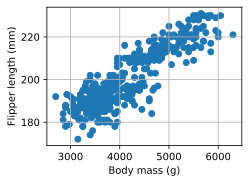

In [ ]:
plot(df['body_mass_g'], df['flipper_length_mm'],
     xlabel='Body mass (g)', ylabel='Flipper length (mm)',
     scatter=True)

## Challenge 2: Predicting Species with a Random Forest

Now that we have loaded and explored the data, let's use it to make predictions. Can we use the six features — bill length, bill depth, flipper length, body mass, island, and sex — to predict which species a penguin belongs to?

We will use a **Random Forest** classifier, a robust and widely-used method that works well out of the box on tabular data.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Separate features (X) and target (y)
# 'species' is the column we want to predict; the remaining six are the predictors
X = df_clean.drop(columns='species').values
y = df_clean['species'].values

# 80/20 train/test split; stratify=y keeps class proportions equal in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# LabelEncoder sorts alphabetically: 0=Adelie, 1=Chinstrap, 2=Gentoo
species_names = ['Adelie', 'Chinstrap', 'Gentoo']

print(f'Training samples: {X_train.shape[0]}')
print(f'Test samples    : {X_test.shape[0]}')

Training samples: 266
Test samples    : 67


### What is a Random Forest?

A Random Forest grows a large number of decision trees, each trained on a random subset of the training data and a random subset of the features. To classify a new penguin, every tree votes for a species and the majority vote wins.

Two sources of randomness make it robust:

- **Bagging** — each tree sees a different bootstrap sample of the data, so no single tree overfits
- **Feature subsampling** — each split considers only a random subset of features, forcing the trees to be diverse

The result is a model that generalises well without requiring feature scaling or extensive hyperparameter tuning.

In [ ]:
# n_estimators=100: grow 100 trees and take a majority vote
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Test accuracy: {accuracy:.1%}')

Test accuracy: 100.0%


### Confusion matrix

A confusion matrix shows, for each actual species (rows), how many penguins were predicted as each species (columns). A perfect classifier has all counts on the diagonal and zeros everywhere else.

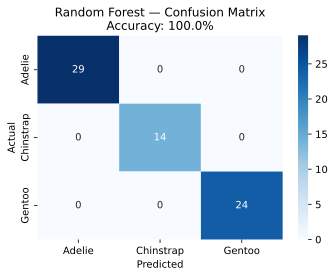

In [ ]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=species_names, yticklabels=species_names, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Random Forest — Confusion Matrix\nAccuracy: {accuracy:.1%}')
plt.tight_layout()
plt.show()

### Feature importance

One advantage of Random Forests over other methods we will see in this course is *interpretability*. After training, we can ask: which features contributed most to the predictions? The feature importance score measures, on average across all trees, how much each feature reduced uncertainty at the splits where it was used.

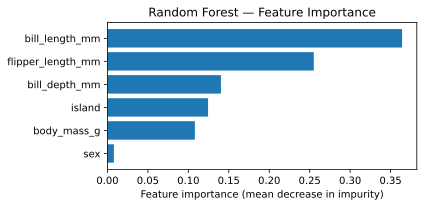

In [ ]:
feature_names = df_clean.drop(columns='species').columns
importances   = rf.feature_importances_

fig, ax = plt.subplots(figsize=(6, 3))
order = np.argsort(importances)
ax.barh(range(len(order)), importances[order], align='center')
ax.set_yticks(range(len(order)))
ax.set_yticklabels(feature_names[order])
ax.set_xlabel('Feature importance (mean decrease in impurity)')
ax.set_title('Random Forest — Feature Importance')
plt.tight_layout()
plt.show()

## Discussion

### Accuracy

The Random Forest achieves high accuracy on this dataset with no preprocessing beyond dropping missing rows and encoding categorical variables. It is scale-invariant—it does not require features to be standardised before training.

### Feature importance

The feature importance plot gives a human-readable answer to the question 'what drives the prediction?'. Features near the top of the chart were the most useful for separating species; those near the bottom contributed little and could potentially be dropped.

